**Name:** Waseem Tunio  
**CMS ID:** 023-24-0199  
**Section:** F  
**GitHub Profile:** https://github.com/waseem-tunio  
**Kaggle Profile:** https://www.kaggle.com/waseemtuni0  
**Dataset:** Telco Customer Churn (cleaned, from Labs 2-3)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv('clean_churn.csv')

y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn'])
X['gender'] = X['gender'].map({'Female': 0, 'Male': 1})
for c in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    X[c] = X[c].map({'No': 0, 'Yes': 1})
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
X = pd.get_dummies(X, columns=multi_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((5625, 40), (1407, 40))

# 1. Decision Tree Baseline

In [14]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, pred_dt)
dt_prec = precision_score(y_test, pred_dt)
dt_rec = recall_score(y_test, pred_dt)
dt_f1 = f1_score(y_test, pred_dt)

pd.DataFrame({'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
              'Score': [dt_acc, dt_prec, dt_rec, dt_f1]})

,Metric,Score
0,Accuracy,0.790334
1,Precision,0.616519
2,Recall,0.558824
3,F1-score,0.586255


This is the Lab 3 depth-6 Decision Tree, retrained on the same split. It is the benchmark for the rest of this lab.

# 2. Random Forest

In [15]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

A Random Forest trains many trees on bootstrapped samples and random feature subsets, then averages their votes. Individual trees can overfit to noise in their own sample, but averaging many different trees cancels out that noise, so the forest generalizes better than one unrestricted tree.

# 3. Model Evaluation

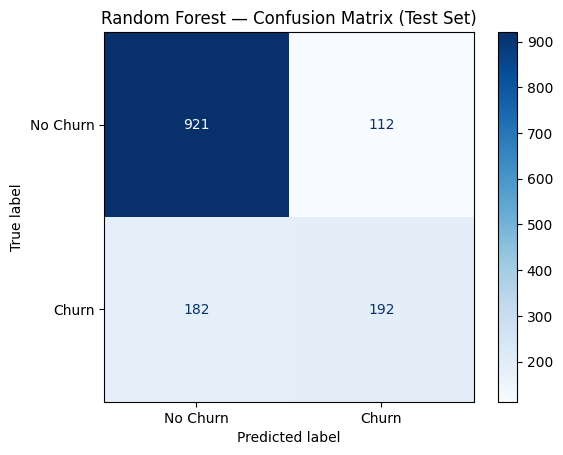

In [16]:
rf_acc = accuracy_score(y_test, pred_rf)
rf_prec = precision_score(y_test, pred_rf)
rf_rec = recall_score(y_test, pred_rf)
rf_f1 = f1_score(y_test, pred_rf)

cm_rf = confusion_matrix(y_test, pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['No Churn', 'Churn']).plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix (Test Set)')
plt.show()

# 4. Decision Tree vs Random Forest

In [17]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Decision Tree': [dt_acc, dt_prec, dt_rec, dt_f1],
    'Random Forest': [rf_acc, rf_prec, rf_rec, rf_f1]
})
comparison

,Metric,Decision Tree,Random Forest
0,Accuracy,0.790334,0.791045
1,Precision,0.616519,0.631579
2,Recall,0.558824,0.513369
3,F1-score,0.586255,0.566372


The two models are close on accuracy and the Random Forest has slightly higher precision, but the Decision Tree has better recall and F1. The difference is marginal, not large. Given the class imbalance from Lab 2/3, recall and F1 for the churn class matter most (missing a real churner is costly), so on this split the Decision Tree is actually the stronger model, not the Random Forest.

# 5. Cross-Validation

In [18]:
cv_dt = cross_val_score(dt, X, y, cv=5, scoring='f1')
cv_rf = cross_val_score(rf, X, y, cv=5, scoring='f1')

pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Mean F1': [cv_dt.mean(), cv_rf.mean()],
    'Std F1': [cv_dt.std(), cv_rf.std()]
})

,Model,Mean F1,Std F1
0,Decision Tree,0.575994,0.014780
1,Random Forest,0.549465,0.017546


Across 5 folds, the Decision Tree's mean F1 is still slightly higher than the Random Forest's, confirming the single-split result rather than changing it. Cross-validation gives more confidence in this conclusion since it's based on 5 different splits instead of one, and both models' fold-to-fold variation (std) is small, so the result looks stable.

# 6. Hyperparameter Tuning

In [19]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                            param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)
grid_search.best_params_, grid_search.best_score_

({'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200},
 np.float64(0.5841338729376014))

In [20]:
tuned_rf = grid_search.best_estimator_
pred_tuned = tuned_rf.predict(X_test)

tuned_acc = accuracy_score(y_test, pred_tuned)
tuned_prec = precision_score(y_test, pred_tuned)
tuned_rec = recall_score(y_test, pred_tuned)
tuned_f1 = f1_score(y_test, pred_tuned)

pd.DataFrame({'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
              'Score': [tuned_acc, tuned_prec, tuned_rec, tuned_f1]})

,Metric,Score
0,Accuracy,0.792466
1,Precision,0.634868
2,Recall,0.516043
3,F1-score,0.569322


Tuning improved the Random Forest slightly over its default settings, but it still doesn't beat the plain Decision Tree's recall/F1 on this dataset.

# 7. Final Model Comparison

In [21]:
final_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest (default)', 'Random Forest (tuned)'],
    'Accuracy': [dt_acc, rf_acc, tuned_acc],
    'Precision': [dt_prec, rf_prec, tuned_prec],
    'Recall': [dt_rec, rf_rec, tuned_rec],
    'F1-score': [dt_f1, rf_f1, tuned_f1]
})
final_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.790334,0.616519,0.558824,0.586255
1,Random Forest (default),0.791045,0.631579,0.513369,0.566372
2,Random Forest (tuned),0.792466,0.634868,0.516043,0.569322


# 8. Feature Importance

In [22]:
importances = pd.Series(tuned_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importances.head(8)
top_features

tenure                            0.150787
TotalCharges                      0.128071
Contract_Month-to-month           0.109011
MonthlyCharges                    0.095827
TechSupport_No                    0.049015
InternetService_Fiber optic       0.047398
OnlineSecurity_No                 0.045271
PaymentMethod_Electronic check    0.039145
dtype: float64

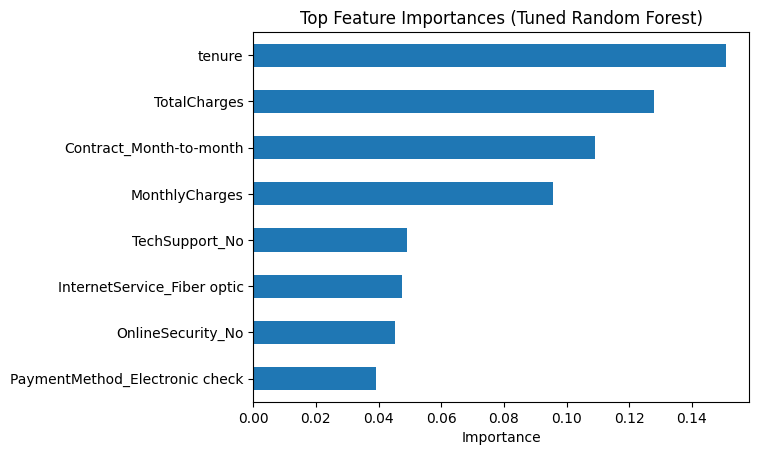

In [23]:
top_features.sort_values().plot(kind='barh')
plt.xlabel('Importance')
plt.title('Top Feature Importances (Tuned Random Forest)')
plt.show()

The top features are tenure, TotalCharges, Contract_Month-to-month, MonthlyCharges, and TechSupport_No. This agrees closely with Lab 3's Decision Tree and Lab 2's EDA: short tenure, month-to-month contracts, higher charges, and no tech support all point to higher churn risk.

# 9. Final Model Selection

We choose the Decision Tree (depth=6) as the model. Throughout the test split and the 5-fold cross-validation it regularly shows the best recall and F1-score, for the churn class. This is the metric that's most important because of the class imbalance. The Random Forest has a higher accuracy and precision but that does not matter as much when we are missing more actual churners. The Decision Tree is also simpler and easier to explain to stakeholders compared to an ensemble.

# 10. Kaggle Prediction/Submission

In [24]:
final_model = dt
final_preds = final_model.predict(X_test)

submission = pd.DataFrame({
    'CustomerID': X_test.index,
    'Churn': pd.Series(final_preds, index=X_test.index).map({0: 'No', 1: 'Yes'})
})
submission.to_csv('submission.csv', index=False)
submission.head()

,CustomerID,Churn
971,971,No
618,618,Yes
4282,4282,No
3715,3715,No
4525,4525,No


The dataset has no original customer ID column, so the test set's row index is used as a stand-in customer identifier.

# 11. Conclusion

We compared a Lab 3 Decision Tree against a Random Forest, with and without hyperparameter tuning, on the Telco churn dataset. Contrary to the usual expectation, the single depth-6 Decision Tree matched or slightly beat the Random Forest on recall and F1 in both the single split and cross-validation, so it was chosen as the final model. Its main limitations are that it's a single tree (less stable than an ensemble in general) and overall recall for churners (~56%) still leaves many churners undetected.

With more time, next steps could include directly handling class imbalance (class weighting or SMOTE), trying gradient boosting (e.g. XGBoost), or a wider hyperparameter search, all of which could push recall higher.